In [58]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") 
options = {"thermal": "lumped","lithium plating": "partially reversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"} #"lithium plating": "irreversible",




In [59]:
model = pybamm.lithium_ion.SPMe(options=options) #DFN or SPM

In [60]:
# %load nialldata_tuneparameters_final.py
#For tuning with base heat cooling for Niall data only
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 10.0,})
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                         
                        })
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3
    EaD = 10000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius
parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 2*1e-12*0.002*0.5}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 42000.0,
                         "SEI partial molar volume [m3.mol-1]": 9.585e-05*0.25,
                         "SEI resistivity [Ohm.m]": 200000.0
                         })  
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 2*0.25*0.5*1.5*0.1/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 2*0.13*0.5*1.5*0.1/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.3,
                         "Negative electrode LAM constant exponential term": 2.3,
                         
                         })






#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 300*5*1e-09*0.001,
                        "Lithium plating transfer coefficient": 0.65,
                        "Dead lithium decay constant [s-1]": 4e-05,
                        
                        })


## HTC 100 for Niall Base cooling

In [61]:
# #For tuning with base heat cooling for Niall data only
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 100.0,})

In [62]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [63]:
from itertools import product


temp_list = [10, 25, 40] #25, 40


all_cases = list(product(temp_list))

df = pd.DataFrame(all_cases,columns = ["Temperature"])
df.insert(0, "Case", range(1, len(df)+1))
df.to_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv", index=False)

In [64]:
df

,Case,Temperature
0,1,10
1,2,25
2,3,40


In [65]:
experimentNiall = pybamm.Experiment(
    [
        (
            "Charge at 0.3C until 4.2 V",
            "Hold at 4.2 V until 50 mA",
            "Rest for 4 hours (10 minute period)",
        ) 
    ]+
    [
      
       (
            "Discharge at 1C until 2.5 V",
            "Charge at 0.3C until 4.2 V",
            "Hold at 4.2 V until 50 mA (10 minute period)",
        )    
    ]
    * 1200
    ,
    termination= "60% capacity"
    ) 

## Case studies for cyclic ageing

Cycling:  59%|█████▊    | 705/1201 [02:40<01:53,  4.38it/s]


Took 2 minutes, 14 seconds


Cycling: 100%|██████████| 1201/1201 [04:37<00:00,  4.33it/s]


Took 3 minutes, 41 seconds


Cycling: 100%|██████████| 1201/1201 [04:43<00:00,  4.23it/s]


Took 3 minutes, 51 seconds


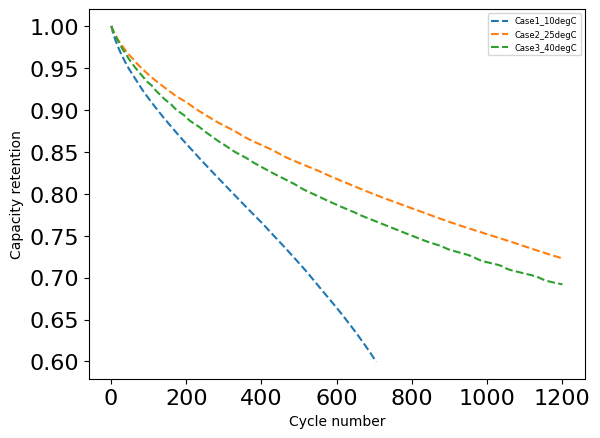

In [66]:

safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 10}) #options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max options={"dt_max": 5}

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)


for n in range(3): #len(df)
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})

   
      

    
    
    sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experimentNiall, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

    mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
    mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
    Qlli = sim1.solution.summary_variables['Loss of lithium inventory [%]']
    Qside = sim1.solution.summary_variables["Total capacity lost to side reactions [A.h]"]
    Qsei  = sim1.solution.summary_variables['Loss of capacity to negative SEI [A.h]']
    
    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Cycle number"] =cycle1
    df2["Capacity Retention"] = Q1/Q1[0]
    df2["LAMpe_per"] =mlam_p
    df2["LAMne_per"] =mlam_n
    df2["Qsei"] = Qsei
    df2["Qpl"] = Qpl
    df2["LLIp"] = Qlli
    df2["Qside"] = Qside


    df2.to_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare_DFN.csv")

    plt.plot(cycle1,Q1/Q1[0],"--", label =f"Case{simcase}_{tempC_case}degC")  #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=6)
    

plt.xlabel("Cycle number")
plt.ylabel("Capacity retention")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()



In [100]:
#pybamm.plot_summary_variables(sim1.solution)

In [ ]:
#sim1.plot()

In [67]:
sim1.plot([
    "Negative electrode porosity",
    "Separator porosity",
    "Positive electrode porosity",
])

interactive(children=(FloatSlider(value=0.0, description='t', max=4539.011952856877, step=45.39011952856877), …

In [ ]:
sim1.plot([
    "Negative lithium plating concentration [mol.m-3]",
    "Loss of capacity to negative lithium plating [A.h]",
    "Negative dead lithium concentration [mol.m-3]"
    
])

In [ ]:
sim1.plot([
    'X-averaged negative SEI thickness [m]',
    "Loss of lithium inventory [%]",
    "Electrolyte concentration [mol.m-3]"

    
])

In [ ]:
pybamm.plot_summary_variables(sim1.solution)

In [ ]:
# t1 = sim1.solution["Time [h]"].entries
# Vc1 = sim1.solution["Terminal voltage [V]"].entries
# Temp1 = sim1.solution["X-averaged cell temperature [K]"].entries

# plt.plot(t1, Vc1)
# plt.show()
# plt.plot(t1, Temp1-273)

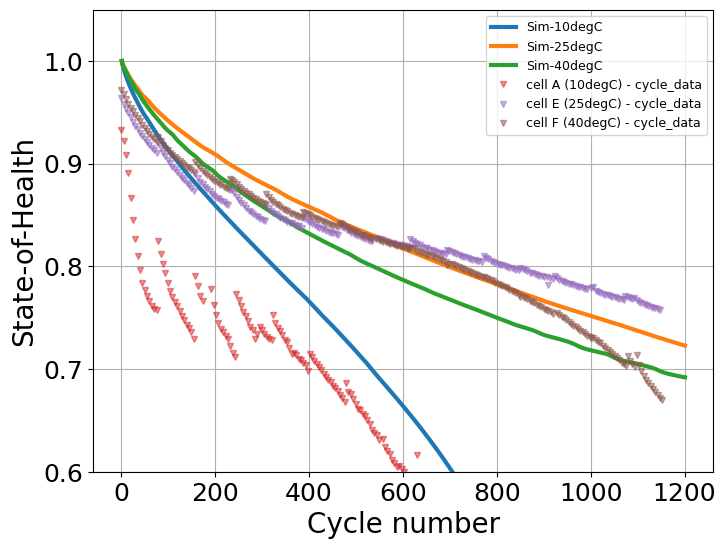

In [68]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv")
cycles_per_day =1
plt.figure(figsize=(8,6))
b =0
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare_DFN.csv")
    plt.plot(df4["Cycle number"], df4["Capacity Retention"], linewidth=3, label =f"Sim-{tempC_case}degC") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")


for m in ["A (10degC)", "E (25degC)", "F (40degC)"]:
    df5 = pd.read_csv(f"{current_directory}/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data//Performance Summary/Expt 5 - cell {m} - Processed Data.csv")
    # plt.plot(df5['Ageing Cycles'], df5['C/10 Capacity [mA h]']/1000/4.865, linestyle="None", marker='o',  linewidth=1, label =f"cell {m}-C/10 RPT Data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in ["A", "E", "F"]:
    if m == "A":
        n = "(10degC)"
    if m == "E":
        n = "(25degC)"
    if m == "F":
        n = "(40degC)"
    
    df4 = pd.read_csv(f"{current_directory}/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell {m} - cycle_data.csv")
    plt.plot(df4["Cycle"], df4['Discharge Capacity [A h]']/4.865, linestyle="None", marker='v',alpha=0.5, markevery=5,markersize=4, linewidth=0.5, label =f"cell {m} {n} - cycle_data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")


plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
#plt.title('SoH',fontsize=20)
plt.ylim([0.6, 1.05])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

In [ ]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv")
cycles_per_day =1
plt.figure(figsize=(8,6))
b =0
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare_DFN.csv")
    plt.plot(df4["Cycle number"], df4["Capacity Retention"], linewidth=3, label =f"Sim-{tempC_case}degC") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")


for m in ["A (10degC)", "E (25degC)", "F (40degC)"]:
    df5 = pd.read_csv(f"{current_directory}/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data//Performance Summary/Expt 5 - cell {m} - Processed Data.csv")
    plt.plot(df5['Ageing Cycles'], df5['C/10 Capacity [mA h]']/1000/4.865, linestyle="None", marker='o',  linewidth=1, label =f"cell {m}-C/10 RPT Data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in ["A", "E", "F"]:
    if m == "A":
        n = "(10degC)"
    if m == "E":
        n = "(25degC)"
    if m == "F":
        n = "(40degC)"
    
    df4 = pd.read_csv(f"{current_directory}/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell {m} - cycle_data.csv")
    plt.plot(df4["Cycle"], df4['Discharge Capacity [A h]']/4.865, linestyle="None", marker='v',alpha=0.5, markevery=5,markersize=4, linewidth=0.5, label =f"cell {m} {n} - cycle_data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")


plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
#plt.title('SoH',fontsize=20)
plt.ylim([0.6, 1.05])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

In [ ]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv")
cycles_per_day =1
plt.figure(figsize=(8,6))
b =0
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare_DFN.csv")
    plt.plot(df4["Cycle number"], df4["Capacity Retention"], linewidth=3, label =f"Sim-{tempC_case}degC") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")


for m in ["A (10degC)", "E (25degC)", "F (40degC)"]:
    df5 = pd.read_csv(f"{current_directory}/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data//Performance Summary/Expt 5 - cell {m} - Processed Data.csv")
    plt.plot(df5['Ageing Cycles'], df5['C/10 Capacity [mA h]']/1000/4.865, linestyle="--", marker='o',  linewidth=1, label =f"cell {m}-C/10 RPT Data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in ["A", "E", "F"]:
    if m == "A":
        n = "(10degC)"
    if m == "E":
        n = "(25degC)"
    if m == "F":
        n = "(40degC)"
    
    df4 = pd.read_csv(f"{current_directory}/Niall_LGM50data/Expt 5 - Standard Cycle Aging (Control)/Summary Data/Ageing Sets Summary/Summary per Cycle/expt 5 - cell {m} - cycle_data.csv")
    plt.plot(df4["Cycle"], df4['Discharge Capacity [A h]']/4.865, linestyle="None", marker='v',alpha=1, markevery=5,markersize=4, linewidth=0.5, label =f"cell {m} {n} - cycle_data") #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")


plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
#plt.title('SoH',fontsize=20)
plt.ylim([0.6, 1.05])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

In [ ]:
current_directory

In [ ]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv")
cycles_per_day =1


fig, axes = plt.subplots(3, 2, figsize=(8,9), sharex=True)
axes = axes.flatten()
for m in range(1):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare_DFN.csv")
    
    xcycle = df4["Cycle number"]
    
    # variables = ["Capacity Retention", "Qside", "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    # variables2 = ["State of health", "Qside", "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ]
    variables = ["Capacity Retention",  "Qsei", "Qpl","LLIp", "LAMne_per", "LAMpe_per",   ]
    variables2 = ["State of health",  "Qsei [A.h]", "Qpl [A.h]", "LLI (%)", "LAMne (%)", "LAMpe (%)",   ] #"Qside",

    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"{tempC_case} degC", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Cycle number", fontsize=12) 
        axes[i].grid(True)
    axes[i].legend()
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


In [ ]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv")
cycles_per_day =1


fig, axes = plt.subplots(3, 2, figsize=(8,9), sharex=True)
axes = axes.flatten()
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare_DFN.csv")
    
    xcycle = df4["Cycle number"]
    
    # variables = ["Capacity Retention", "Qside", "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    # variables2 = ["State of health", "Qside", "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ]
    variables = ["Capacity Retention",  "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    variables2 = ["State of health",  "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ] #"Qside",

    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"{tempC_case} degC", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Cycle number", fontsize=12) 
        axes[i].grid(True)
    axes[i].legend()
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


In [ ]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Cases_expdata.csv")
cycles_per_day =1


fig, axes = plt.subplots(4, 2, figsize=(8,9), sharex=True)
axes = axes.flatten()
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/compareData/Case{simcase}_{tempC_case}degC_sim_dataCompare_DFN.csv")
    
    xcycle = df4["Cycle number"]
    
    variables = ["Capacity Retention", "Qside", "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    variables2 = ["State of health", "Qside", "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ]
    # variables = ["Capacity Retention",  "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    # variables2 = ["State of health",  "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ] #"Qside",

    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"{tempC_case} degC", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Cycle number", fontsize=12) 
        axes[i].grid(True)
    axes[i].legend()
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


In [ ]:
model.summary_variables